In [ ]:
# Upload test.json from local storage
from google.colab import files
uploaded = files.upload()

Saving test.json to test.json


# Set up

In [2]:
!pip install jiwer tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.1 MB/s eta 0:00:00


In [3]:
import torch
from jiwer import cer
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Get (untrained & trained) model + Load test dataset

In [4]:
model_checkpoint = "vietai/vit5-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/904M [00:00<?, ?B/s]

In [5]:
import shutil

for folder_name in ["trained", "trained_1_epoch"]:
  source = f'/content/drive/MyDrive/{folder_name}'
  destination = f'/content/{folder_name}'

  try:
      from google.colab import drive
      drive.mount('/content/drive')

      shutil.copytree(source, destination)
      print("Copy thành công!")
  except FileExistsError:
      print("Thư mục đích đã tồn tại.")

Mounted at /content/drive
Copy thành công!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copy thành công!


In [6]:
import json

with open("test.json", "r", encoding='utf-8') as f:
    test_dataset = json.load(f)

# Load model function

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
import os
import glob
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

def load_model(base_path):
  if os.path.exists(os.path.join(base_path, "config.json")):
      final_path = base_path
  else:
      checkpoints = glob.glob(os.path.join(base_path, "checkpoint-*"))
      if len(checkpoints) > 0:
          final_path = max(checkpoints, key=lambda x: int(x.split("-")[-1]))
      else:
          raise ValueError("Không tìm thấy model/checkpoint!")

  tokenizer = AutoTokenizer.from_pretrained(final_path)
  model = AutoModelForSeq2SeqLM.from_pretrained(final_path)
  model.to(device)

  return model, tokenizer

# Testing + Evaluation functions

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def correct_sentence(model, tokenizer, text):
    model.to(device)
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True)
    inputs = inputs.to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=128,
            num_beams=5,
            early_stopping=True
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

def evaluate_dataset(model, tokenizer, dataset):
    """
    Args:
        dataset: List các dict [{"input": "...", "output": "..."}, ...]
    Returns:
        list_cers: Danh sách điểm CER của từng câu.
        results: Danh sách chi tiết (để debug).
    """
    list_cers = []
    results = []

    print(f"Đang đánh giá {len(dataset)} mẫu dữ liệu...")

    for item in tqdm(dataset):
        input_text = item['input']
        target_text = item['target']

        prediction = correct_sentence(model, tokenizer, input_text)

        if not target_text.strip():
            score = 1.0 if prediction.strip() else 0.0
        else:
            score = cer(target_text, prediction)

        list_cers.append(score)
        results.append({
            "input": input_text,
            "target": target_text,
            "prediction": prediction,
            "cer": score
        })

    avg_cer = sum(list_cers) / len(list_cers) if list_cers else 0
    print(f"\n=== KẾT QUẢ ===")
    print(f"CER Trung bình: {avg_cer:.4f}")

    return list_cers, results

def draw_histogram(cer_list, title):
  plt.figure(figsize=(10, 6))
  plt.hist(cer_list, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
  avg_cer = np.mean(cer_list)
  plt.axvline(avg_cer, color='red', linestyle='dashed', linewidth=1.5, label=f'Trung bình: {avg_cer:.4f}')

  plt.title(title, fontsize=14)
  plt.xlabel('Độ lỗi CER', fontsize=12)
  plt.ylabel('Số lượng câu', fontsize=12)
  plt.legend()
  plt.grid(axis='y', alpha=0.5)

  plt.show()

def draw_scatter_plot(cer_list, title):
  mean_cer = np.mean(cer_list)
  plt.figure(figsize=(12, 6))

  plt.scatter(range(len(cer_list)), cer_list, alpha=0.6, s=15, label='Mẫu dữ liệu')

  plt.axhline(y=mean_cer, color='r', linestyle='--', linewidth=2, label=f'Trung bình: {mean_cer:.4f}')

  plt.title(title)
  plt.xlabel('Index của dữ liệu')
  plt.ylabel('Độ lỗi CER')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

**Test on trained-1-epoch model**

In [ ]:
model, tokenizer = load_model("trained_1_epoch")
cer_list_1, details_1 = evaluate_dataset(model, tokenizer, test_dataset)

with open("details_1.json", "w", encoding='utf-8') as f:
  json.dump(details_1, f, ensure_ascii=False, indent=2)

Đang đánh giá 1423 mẫu dữ liệu...


100%|██████████| 1423/1423 [09:23<00:00,  2.53it/s]


=== KẾT QUẢ ===
CER Trung bình: 0.1044


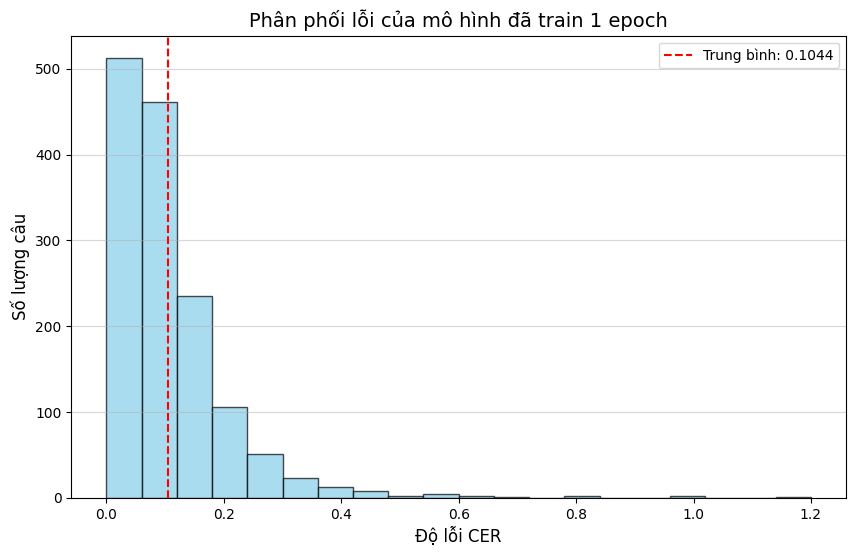

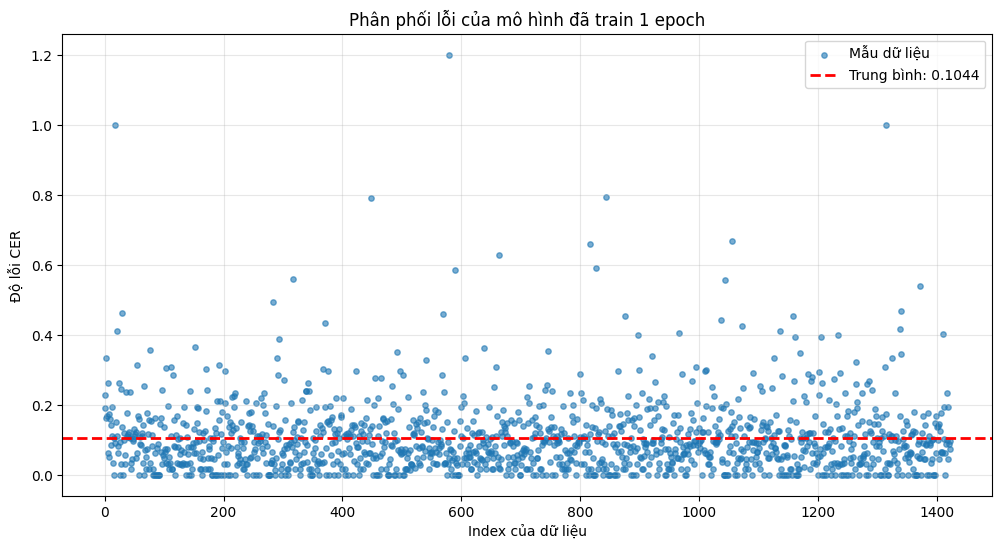

In [29]:
draw_histogram(cer_list_1, "Phân phối lỗi của mô hình đã train 1 epoch")
draw_scatter_plot(cer_list_1, "Phân phối lỗi của mô hình đã train 1 epoch")

**Test on final model**

In [ ]:
model, tokenizer = load_model("trained")
cer_list, details = evaluate_dataset(model, tokenizer, test_dataset)

with open("details.json", "w", encoding='utf-8') as f:
  json.dump(details, f, ensure_ascii=False, indent=2)

Đang đánh giá 1423 mẫu dữ liệu...


100%|██████████| 1423/1423 [08:59<00:00,  2.64it/s]


=== KẾT QUẢ ===
CER Trung bình: 0.1135


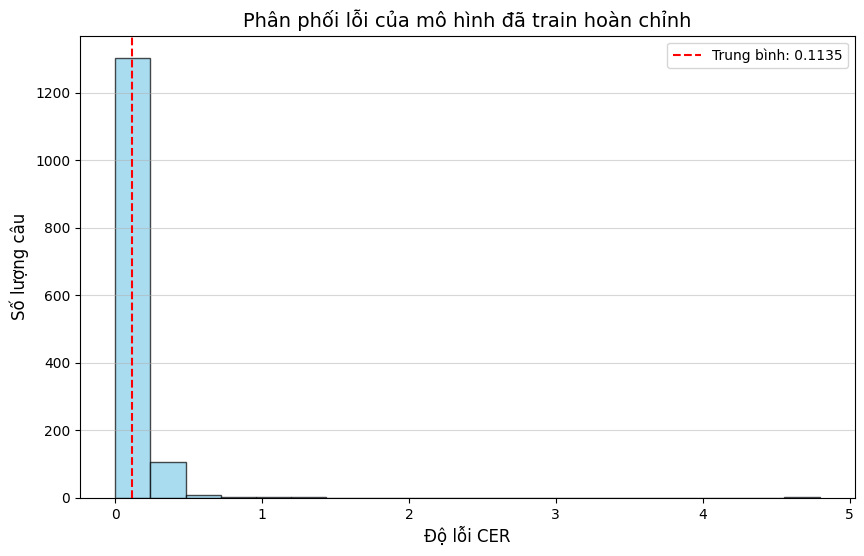

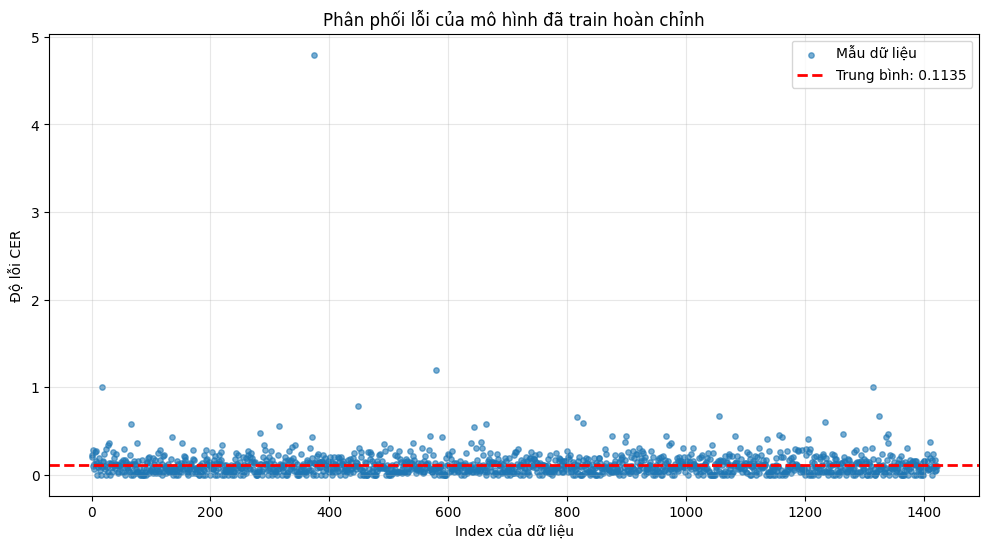

In [28]:
draw_histogram(cer_list, "Phân phối lỗi của mô hình đã train hoàn chỉnh")
draw_scatter_plot(cer_list, "Phân phối lỗi của mô hình đã train hoàn chỉnh")

**Đánh giá sâu hơn**

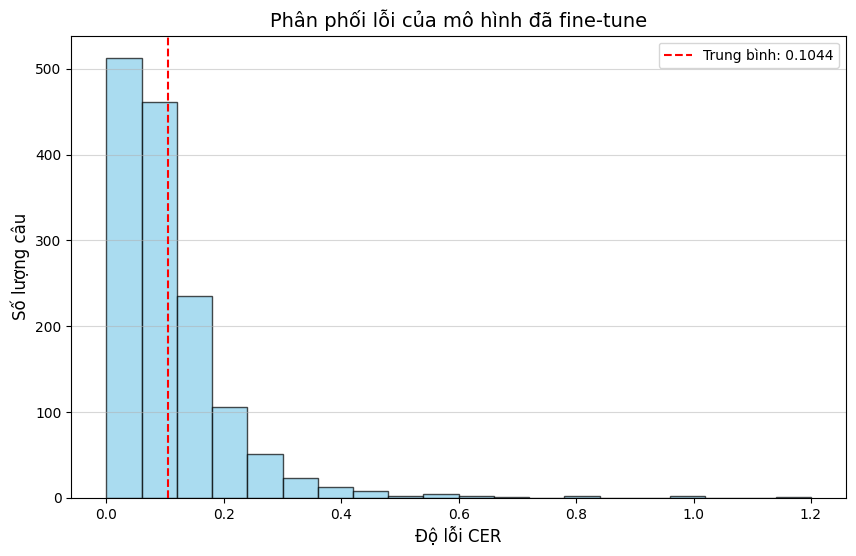

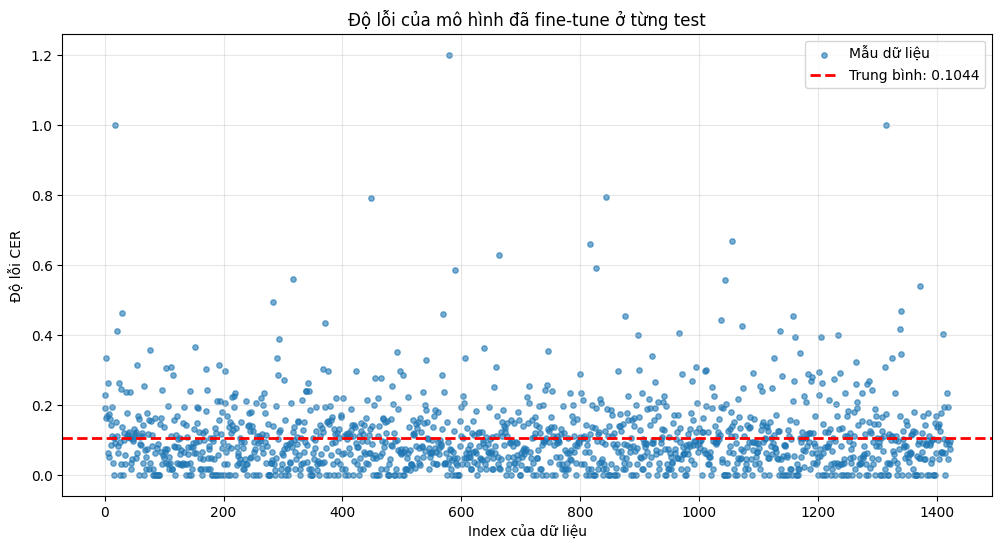

In [10]:
import json
with open("details_1.json", "r", encoding="utf-8") as f:
    cer_list = [d["cer"] for d in json.load(f) if d["cer"] <= 1.5]

draw_histogram(cer_list, "Phân phối lỗi của mô hình đã fine-tune")
draw_scatter_plot(cer_list, "Độ lỗi của mô hình đã fine-tune ở từng test")


In [13]:
count_0 = 0
count_outliers = 0
for cer in cer_list: count_0 += cer == 0.0
for cer in cer_list: count_outliers += cer > 0.5

print("Số test:", len(cer_list))
print(count_0, count_0 / len(cer_list))
print(count_outliers, count_outliers / len(cer_list))

Số test: 1423
161 0.11314125087842586
13 0.009135628952916374


# Quick test

In [32]:
model_paths = ["trained_1_epoch", "trained"]
input_text = "t\u00f9y b\u00e0c thu\u00f2 ng cho bac v\u00e0 lua."
print("Input text:", input_text)

model_checkpoint = "vietai/vit5-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

print("Original model prediction:", correct_sentence(model, tokenizer, input_text))

for model_path in model_paths:
  model, tokenizer = load_model(model_path)
  print(f"{model_path} prediction: {correct_sentence(model, tokenizer, input_text)}")


Input text: tùy bàc thuò ng cho bac và lua.
Original model prediction: * tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc tùy bàc
trained_1_epoch prediction: tùy bậc thưởng phạt cho bạc và lụa.
trained prediction: tùy bậc thưởng cho bạc và lụa.
